In [1]:
import scipy.linalg as la
from qiskit import QuantumCircuit, QuantumRegister, transpile
%matplotlib inline
import numpy as np
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from iqm.qiskit_iqm.fake_backends import fake_aphrodite
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import AerSimulator

In [2]:
# Function for generating calibration circuits for the chosen number of qubits
def calibration_circuits(num_qubits):
    circuits = []
    for i in range(2**num_qubits):
        state = reversed(format(i, f'0{num_qubits}b'))
        qc = QuantumCircuit(num_qubits, num_qubits)
        
        for j, bit in enumerate(state):
            if bit == '1':
                qc.x(j)
        
        qc.measure(range(num_qubits), range(num_qubits))
        circuits.append(qc)
    
    return circuits

# Function for generating a mitigation matrix from the calibration results
def mitigation_matrix(calibration_results, num_qubits):
    num_states = 2**num_qubits
    M = np.zeros((num_states, num_states))
    
    for state_index in range(num_states):
        counts = calibration_results.get_counts(state_index)
        total_shots = sum(counts.values())
        
        for measured_state, count in counts.items():
            measured_state_index = int(measured_state, 2)
            M[measured_state_index, state_index] = count / total_shots
    
    return M

# Function that applies inverse of mitigation matrix to noisy counts to obtain mitigatated counts
def mitigate_counts(noisy_counts, Minv, num_qubits, shots):
    counts_vector = np.zeros(2**num_qubits)
    for state, count in noisy_counts.items():
        index = int(state, 2)
        counts_vector[index] = count
    
    mitigated_vector = np.dot(Minv, counts_vector)
    
    mitigated_vector = np.maximum(mitigated_vector, 0)
    mitigated_vector = mitigated_vector * shots / np.sum(mitigated_vector)
    
    mitigated_counts = {}
    for i in range(len(mitigated_vector)):
        state = format(i, f'0{num_qubits}b')
        mitigated_counts[state] = round(mitigated_vector[i])
    
    return mitigated_counts

In [3]:
# Choosing backend
backend = fake_aphrodite.IQMFakeAphrodite()

num_qubits = 4          # Number of qubits
layout = [10,11,18,19]  # Qubits for initial layout
shots = 10000           # Number of shots

# Generating and running calibration circuits
calibration_circuits_1 = calibration_circuits(num_qubits)
calibration_circuits = transpile(calibration_circuits_1, backend=backend, initial_layout=layout, optimization_level=3) 
calibration_job = backend.run(calibration_circuits, shots=shots)
calibration_results = calibration_job.result()
print("Calibration results:")
print(calibration_results.get_counts())
    
# Building mitigation matrix
M = mitigation_matrix(calibration_results, num_qubits)
print()
print("Calibration matrix M:")
print(M)
    
# Calculating inverse matrix
Minv = la.inv(M)
print()
print("Inverse matrix Minv:")
print(Minv)

Calibration results:
[{'1110': 2, '1011': 4, '0000': 8063, '0010': 445, '1100': 20, '0100': 432, '0001': 444, '0011': 16, '0111': 2, '1001': 29, '0101': 27, '1010': 26, '1000': 466, '0110': 23, '1101': 1}, {'1111': 2, '0001': 8016, '1011': 37, '0011': 437, '0111': 23, '0000': 452, '0010': 21, '0101': 442, '1001': 484, '0100': 31, '1101': 24, '1000': 29, '0110': 1, '1010': 1}, {'1111': 1, '1100': 2, '0010': 8050, '0000': 442, '1010': 490, '1011': 26, '0011': 487, '0111': 17, '0110': 395, '1000': 19, '0100': 24, '1110': 21, '1001': 4, '0101': 2, '0001': 20}, {'1110': 1, '1011': 496, '0011': 8085, '0111': 423, '0001': 416, '1111': 25, '0010': 413, '0000': 31, '1010': 31, '0101': 29, '1001': 24, '0110': 24, '1000': 1, '0100': 1}, {'1010': 3, '0101': 480, '1110': 24, '0100': 8017, '0000': 425, '0010': 17, '1101': 24, '1100': 510, '0110': 433, '1000': 17, '0111': 24, '0011': 3, '0001': 21, '1111': 2}, {'0000': 25, '1000': 1, '1100': 25, '1001': 31, '0100': 434, '1111': 25, '0001': 448, '1011

Noiseless counts {'1110': 1, '1100': 3, '0000': 9996}
Noisy counts: {'1101': 37, '1111': 85, '1011': 27, '0000': 6387, '0010': 456, '1110': 181, '0001': 394, '0111': 53, '0011': 151, '1010': 211, '1100': 340, '0101': 194, '1001': 53, '0100': 533, '1000': 672, '0110': 226}
Mitigated counts: {'0000': 7880, '0001': 33, '0010': 94, '0011': 160, '0100': 191, '0101': 197, '0110': 229, '0111': 24, '1000': 350, '1001': 11, '1010': 199, '1011': 0, '1100': 363, '1101': 5, '1110': 175, '1111': 90}


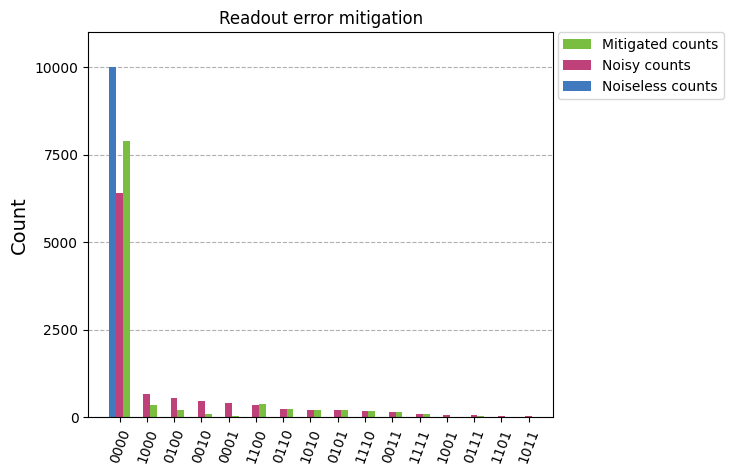

In [4]:
# Defining circuit to be run
qc = EfficientSU2(num_qubits=num_qubits, entanglement="linear")
x0 = np.random.normal(0, 0.01, qc.num_parameters) 
qc = qc.assign_parameters(x0)
qc.measure_all()
    
# Getting noisy results
noisy_result_1 = transpile(qc, backend=backend, initial_layout=layout, optimization_level=3)
noisy_result = backend.run(noisy_result_1, shots=shots).result()
noisy_counts = noisy_result.get_counts()
    
# Getting mitigated results
mitigated_counts = mitigate_counts(noisy_counts, Minv, num_qubits, shots)
noiseless_counts = AerSimulator().run(qc.decompose(), shots=10000).result().get_counts()

# Printing counts
print("Noiseless counts", noiseless_counts)
print("Noisy counts:", noisy_counts)
print("Mitigated counts:", mitigated_counts)
    
# Plotting results
legend = ['Mitigated counts', 'Noisy counts', 'Noiseless counts']
fig = plot_histogram([mitigated_counts, noisy_counts, noiseless_counts], legend=legend, color=['#79BE41','#BE4179','#4179BE'], title="Readout error mitigation", sort="value_desc", bar_labels=False, figsize=[6,5])
fig.savefig("Readout_error_mitigation")

Noiseless counts {'0000': 5001, '0011': 4999}
Noisy counts: {'1111': 10, '0000': 4031, '0010': 474, '0011': 3990, '0111': 246, '1011': 220, '1100': 11, '0101': 28, '1001': 23, '0100': 228, '0001': 463, '1000': 225, '0110': 25, '1101': 1, '1010': 25}
Mitigated counts: {'0000': 4942, '0001': 47, '0010': 61, '0011': 4886, '0100': 16, '0101': 0, '0110': 0, '0111': 46, '1000': 0, '1001': 0, '1010': 0, '1011': 0, '1100': 1, '1101': 1, '1110': 0, '1111': 0}


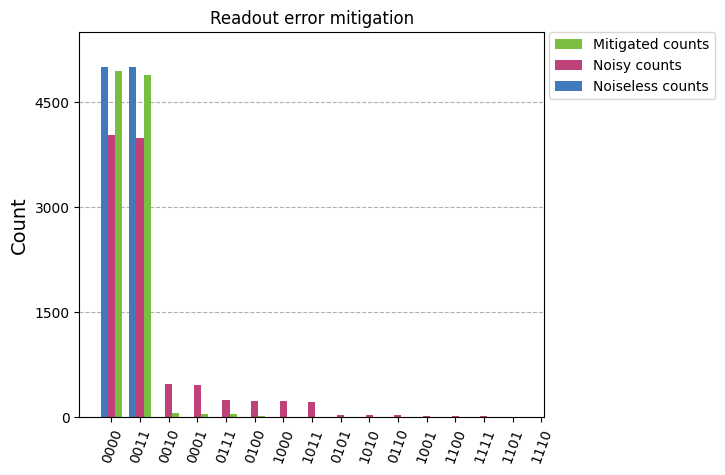

In [5]:
# Defining circuit to be run
qc = QuantumCircuit(4,4)
qc.h(0)
qc.cx(0,1)  
qc.measure(qc.qregs[0],qc.cregs[0])

# Getting noisy results
noisy_result_1 = transpile(qc, backend=backend, optimization_level=3)
noisy_result = backend.run(noisy_result_1, shots=shots).result()
noisy_counts = noisy_result.get_counts()
    
# Getting mitigated results
mitigated_counts = mitigate_counts(noisy_counts, Minv, num_qubits, shots)
noiseless_counts = AerSimulator().run(qc.decompose(), shots=10000).result().get_counts()

# Printing counts
print("Noiseless counts", noiseless_counts)
print("Noisy counts:", noisy_counts)
print("Mitigated counts:", mitigated_counts)
    
# Plotting results
legend = ['Mitigated counts', 'Noisy counts', 'Noiseless counts']
fig = plot_histogram([mitigated_counts, noisy_counts, noiseless_counts], legend=legend, color=['#79BE41','#BE4179','#4179BE'], title="Readout error mitigation", sort="value_desc", bar_labels=False, figsize=[6,5])
fig.savefig("Readout_error_mitigation")

Noiseless counts {'1111': 5010, '0000': 4990}
Noisy counts: {'1010': 26, '0000': 3803, '0010': 189, '0110': 25, '1000': 274, '1100': 90, '0101': 25, '1001': 34, '1111': 3890, '0001': 323, '1011': 240, '0111': 248, '0011': 90, '1110': 316, '0100': 205, '1101': 222}
Mitigated counts: {'0000': 4676, '0001': 137, '0010': 0, '0011': 74, '0100': 0, '0101': 0, '0110': 0, '0111': 31, '1000': 63, '1001': 0, '1010': 0, '1011': 26, '1100': 74, '1101': 20, '1110': 128, '1111': 4771}


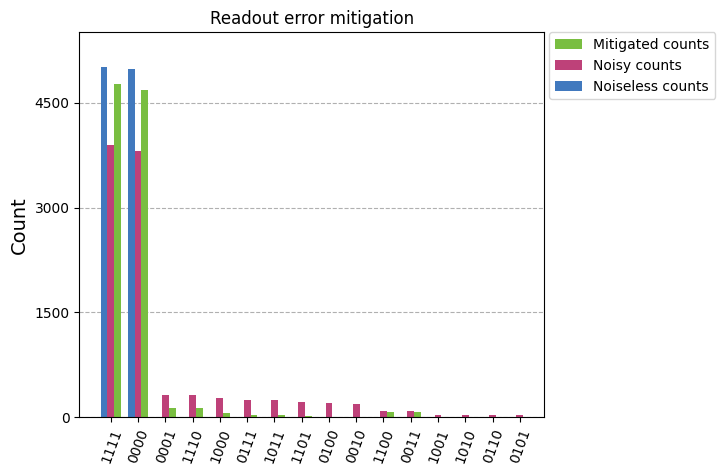

In [6]:
# Defining circuit to be run
qc = QuantumCircuit(num_qubits)
qc.sx(0)
for i in range(1, num_qubits):
    qc.cx(i - 1, i)
qc.measure_all()

# Getting noisy results
noisy_result_1 = transpile(qc, backend=backend, optimization_level=3)
noisy_result = backend.run(noisy_result_1, shots=shots).result()
noisy_counts = noisy_result.get_counts()
    
# Getting mitigated results
mitigated_counts = mitigate_counts(noisy_counts, Minv, num_qubits, shots)

# Getting noiseless counts
noiseless_counts = AerSimulator().run(qc.decompose(), shots=10000).result().get_counts()

# Printing counts
print("Noiseless counts", noiseless_counts)
print("Noisy counts:", noisy_counts)
print("Mitigated counts:", mitigated_counts)
    
# Plotting results
legend = ['Mitigated counts', 'Noisy counts', 'Noiseless counts']
fig = plot_histogram([mitigated_counts, noisy_counts, noiseless_counts], legend=legend, color=['#79BE41','#BE4179','#4179BE'], title="Readout error mitigation", sort="value_desc", bar_labels=False, figsize=[6,5])
fig.savefig("Readout_error_mitigation")